<a href="https://colab.research.google.com/github/aisha13dikko-sudo/using-synthetic-data-for-thermal-comfort-classification/blob/main/experiments/sdv_baseline_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

install SDV

In [1]:
# This installs SDV into your Colab session
# You need to run this every time you open a new Colab session
!pip install sdv --quiet
print("✅ SDV installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.9/206.9 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 136.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 100.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 11.2 MB/s eta 0:00:00
✅ SDV installed successfully!


imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# SDV tools
from sdv.datasets.demo import download_demo
from sdv.single_table import GaussianCopulaSynthesizer
from sdv.single_table import CTGANSynthesizer
from sdv.evaluation.single_table import evaluate_quality

# Classifier tools
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, balanced_accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

print("✅ All imports ready!")

✅ All imports ready!


load demo data and explore

In [3]:
# Load SDV's built-in demo dataset (fictional hotel guests)
# This is a STAND-IN for your AutoTherm data — same structure, different content
real_data, metadata = download_demo(
    modality='single_table',
    dataset_name='fake_hotel_guests'
)

print(f"Rows: {real_data.shape[0]},  Columns: {real_data.shape[1]}")
print("\nColumn names:")
print(real_data.columns.tolist())
print("\nFirst 5 rows:")
real_data.head()

Rows: 500,  Columns: 9

Column names:
['guest_email', 'has_rewards', 'room_type', 'amenities_fee', 'checkin_date', 'checkout_date', 'room_rate', 'billing_address', 'credit_card_number']

First 5 rows:


,guest_email,has_rewards,room_type,amenities_fee,checkin_date,checkout_date,room_rate,billing_address,credit_card_number
0,michaelsanders@shaw.net,False,BASIC,37.89,27 Dec 2020,29 Dec 2020,131.23,"49380 Rivers Street\nSpencerville, AK 68265",4075084747483975747
1,randy49@brown.biz,False,BASIC,24.37,30 Dec 2020,02 Jan 2021,114.43,"88394 Boyle Meadows\nConleyberg, TN 22063",180072822063468
2,webermelissa@neal.com,True,DELUXE,0.00,17 Sep 2020,18 Sep 2020,368.33,"0323 Lisa Station Apt. 208\nPort Thomas, LA 82585",38983476971380
3,gsims@terry.com,False,BASIC,NaN,28 Dec 2020,31 Dec 2020,115.61,"77 Massachusetts Ave\nCambridge, MA 02139",4969551998845740
4,misty33@smith.biz,False,BASIC,16.45,05 Apr 2020,NaN,122.41,"1234 Corporate Drive\nBoston, MA 02116",3558512986488983


check imbalance

Class distribution:
room_type
BASIC     384
DELUXE     78
SUITE      38
Name: count, dtype: int64


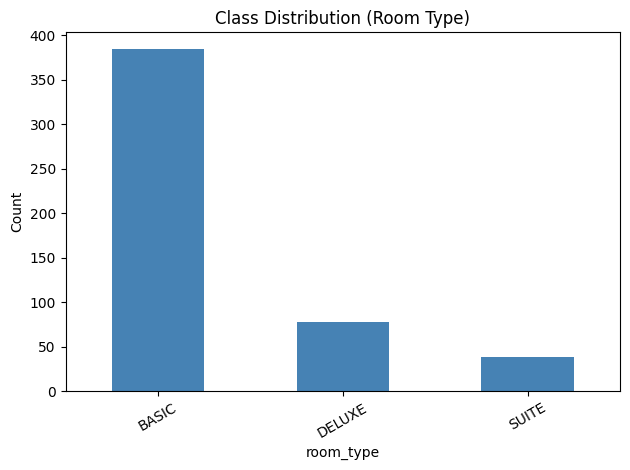

In [4]:
# This is the SAME problem you have in AutoTherm — unequal class sizes
print("Class distribution:")
print(real_data['room_type'].value_counts())

# Visualise it
real_data['room_type'].value_counts().plot(
    kind='bar', color='steelblue', title='Class Distribution (Room Type)'
)
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

baseline classifier (real data only)

In [5]:
# ── Prepare features ──────────────────────────────────────────────
drop_cols  = ['guest_email', 'billing_address', 'credit_card_number']
target_col = 'room_type'

features_df = real_data.drop(columns=drop_cols, errors='ignore')
X = features_df.drop(columns=[target_col])
y = features_df[target_col]

# Convert text columns to numbers
for col in X.select_dtypes(include=['object','category']).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# Convert dates to numbers
for col in X.select_dtypes(include=['datetime64']).columns:
    X[col] = X[col].astype(np.int64)

X = X.fillna(X.median(numeric_only=True))

# Encode labels
le_target    = LabelEncoder()
y_encoded    = le_target.fit_transform(y)

# Train/test split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# ── Train Random Forest ───────────────────────────────────────────
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# ── Results ───────────────────────────────────────────────────────
print("📊 BASELINE — Train Real, Test Real")
print(f"Macro F1:          {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

📊 BASELINE — Train Real, Test Real
Macro F1:          0.7734
Balanced Accuracy: 0.7608

              precision    recall  f1-score   support

       BASIC       0.94      0.96      0.95        77
      DELUXE       0.86      0.75      0.80        16
       SUITE       0.57      0.57      0.57         7

    accuracy                           0.90       100
   macro avg       0.79      0.76      0.77       100
weighted avg       0.90      0.90      0.90       100



generate synthetic data with gaussian copula

In [6]:
# Fit Gaussian Copula to real data
gc = GaussianCopulaSynthesizer(metadata)
gc.fit(real_data)

# Generate same number of rows as real data
gc_synthetic = gc.sample(num_rows=len(real_data))

print("✅ Gaussian Copula synthetic data generated!")
print(f"Shape: {gc_synthetic.shape}")
gc_synthetic.head()

✅ Gaussian Copula synthetic data generated!
Shape: (500, 9)


,guest_email,has_rewards,room_type,amenities_fee,checkin_date,checkout_date,room_rate,billing_address,credit_card_number
0,dsullivan@example.net,False,BASIC,0.29,27 Mar 2020,09 Mar 2020,135.15,"90469 Karla Knolls Apt. 781\nSusanberg, CA 70033",5161033759518983
1,steven59@example.org,False,DELUXE,8.15,07 Sep 2020,25 Jun 2020,183.24,"6108 Carla Ports Apt. 116\nPort Evan, MI 71694",4133047413145475690
2,brandon15@example.net,False,BASIC,11.65,22 Mar 2020,01 Apr 2020,163.57,86709 Jeremy Manors Apt. 786\nPort Garychester...,4977328103788
3,humphreyjennifer@example.net,False,BASIC,48.12,04 Jun 2020,14 May 2020,127.75,"8906 Bobby Trail\nEast Sandra, NY 43986",3524946844839485
4,joshuabrown@example.net,False,DELUXE,11.07,08 Jan 2020,13 Jan 2020,180.12,"732 Dennis Lane\nPort Nicholasstad, DE 49786",4446905799576890978


fidelity check

In [7]:
# This compares real vs synthetic statistically
# Column Shapes  = are individual column distributions similar?
# Column Pairs   = are correlations between columns preserved?
quality = evaluate_quality(real_data, gc_synthetic, metadata)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 9/9 [00:00<00:00, 861.21it/s]|
Column Shapes Score: 90.06%

(2/2) Evaluating Column Pair Trends: |██████████| 36/36 [00:00<00:00, 410.73it/s]|
Column Pair Trends Score: 83.47%

Overall Score (Average): 86.76%



TSTR with gaussian copula

In [8]:
# Helper function — we'll reuse this for every method
def prepare_features(df, drop_cols, target_col, ref_columns, le_target):
    df = df.drop(columns=drop_cols, errors='ignore')
    y  = df[target_col]
    X  = df.drop(columns=[target_col])
    for col in X.select_dtypes(include=['object','category']).columns:
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))
    for col in X.select_dtypes(include=['datetime64']).columns:
        X[col] = X[col].astype(np.int64)
    X = X.fillna(X.median(numeric_only=True))
    X = X.reindex(columns=ref_columns, fill_value=0)
    y_enc = le_target.transform(
        y.apply(lambda v: v if v in le_target.classes_ else le_target.classes_[0])
    )
    return X, y_enc

# Prepare synthetic data
X_gc, y_gc = prepare_features(gc_synthetic, drop_cols, target_col, X.columns, le_target)

# Train on SYNTHETIC, test on REAL
clf_gc = RandomForestClassifier(n_estimators=100, random_state=42)
clf_gc.fit(X_gc, y_gc)
y_pred_gc = clf_gc.predict(X_test)

print("📊 GAUSSIAN COPULA — TSTR (Train Synthetic, Test Real)")
print(f"Macro F1:          {f1_score(y_test, y_pred_gc, average='macro'):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_gc):.4f}")

📊 GAUSSIAN COPULA — TSTR (Train Synthetic, Test Real)
Macro F1:          0.5210
Balanced Accuracy: 0.4867


CTGAN deep learning method

In [9]:
# epochs=50 is low — for the real project use 300+
# Higher epochs = better quality BUT longer training time
ctgan = CTGANSynthesizer(metadata, epochs=50, verbose=True)
ctgan.fit(real_data)

ctgan_synthetic = ctgan.sample(num_rows=len(real_data))
print("✅ CTGAN synthetic data generated!")

# TSTR with CTGAN
X_ct, y_ct = prepare_features(ctgan_synthetic, drop_cols, target_col, X.columns, le_target)

clf_ct = RandomForestClassifier(n_estimators=100, random_state=42)
clf_ct.fit(X_ct, y_ct)
y_pred_ct = clf_ct.predict(X_test)

print("\n📊 CTGAN — TSTR")
print(f"Macro F1:          {f1_score(y_test, y_pred_ct, average='macro'):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_ct):.4f}")

Gen. (+00.91) | Discrim. (-00.04): 100%|██████████| 50/50 [00:02<00:00, 20.71it/s]


✅ CTGAN synthetic data generated!

📊 CTGAN — TSTR
Macro F1:          0.2900
Balanced Accuracy: 0.3333


final comparison table and chart

              Method  Macro F1  Balanced Accuracy
Baseline (Real→Real)    0.7734             0.7608
 GaussianCopula TSTR    0.5210             0.4867
          CTGAN TSTR    0.2900             0.3333


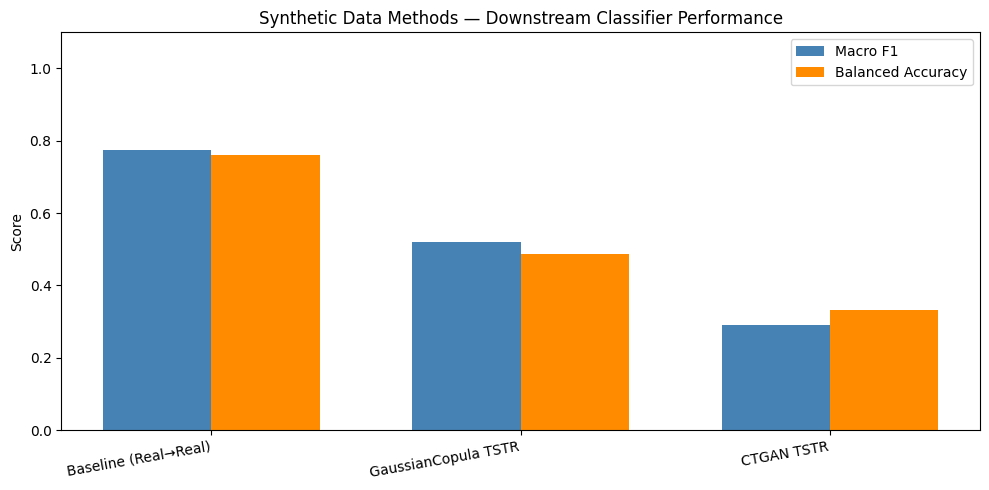

In [10]:
results = pd.DataFrame({
    'Method': ['Baseline (Real→Real)', 'GaussianCopula TSTR', 'CTGAN TSTR'],
    'Macro F1': [
        f1_score(y_test, y_pred,    average='macro'),
        f1_score(y_test, y_pred_gc, average='macro'),
        f1_score(y_test, y_pred_ct, average='macro'),
    ],
    'Balanced Accuracy': [
        balanced_accuracy_score(y_test, y_pred),
        balanced_accuracy_score(y_test, y_pred_gc),
        balanced_accuracy_score(y_test, y_pred_ct),
    ]
}).round(4)

print(results.to_string(index=False))

# Bar chart
x = np.arange(3)
w = 0.35
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(x - w/2, results['Macro F1'],         w, label='Macro F1',         color='steelblue')
ax.bar(x + w/2, results['Balanced Accuracy'], w, label='Balanced Accuracy', color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(results['Method'], rotation=10, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Synthetic Data Methods — Downstream Classifier Performance')
ax.legend()
plt.tight_layout()
plt.show()

CTGAN with 300 epochs

In [11]:
# The proper CTGAN run — 300 epochs
# This will take ~5-10 minutes in Colab. Let it run.
ctgan_proper = CTGANSynthesizer(metadata, epochs=300, verbose=True)
ctgan_proper.fit(real_data)
ctgan_proper_synthetic = ctgan_proper.sample(num_rows=len(real_data))

X_ct300, y_ct300 = prepare_features(
    ctgan_proper_synthetic, drop_cols, target_col, X.columns, le_target
)
clf_ct300 = RandomForestClassifier(n_estimators=100, random_state=42)
clf_ct300.fit(X_ct300, y_ct300)
y_pred_ct300 = clf_ct300.predict(X_test)

print("📊 CTGAN 300 epochs — TSTR")
print(f"Macro F1:          {f1_score(y_test, y_pred_ct300, average='macro'):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_ct300):.4f}")
print()
print("Compare to CTGAN 50 epochs:")
print(f"  50 epochs Macro F1:  {f1_score(y_test, y_pred_ct, average='macro'):.4f}")
print(f" 300 epochs Macro F1:  {f1_score(y_test, y_pred_ct300, average='macro'):.4f}")

Gen. (-01.12) | Discrim. (+00.13): 100%|██████████| 300/300 [00:07<00:00, 40.96it/s]


📊 CTGAN 300 epochs — TSTR
Macro F1:          0.2810
Balanced Accuracy: 0.3111

Compare to CTGAN 50 epochs:
  50 epochs Macro F1:  0.2900
 300 epochs Macro F1:  0.2810


real + synthetic combined

In [12]:
# Augmented = mix real training data WITH synthetic data
# This is often better than TSTR because you keep all real data AND add synthetic

# Real + GaussianCopula
X_aug_gc = pd.concat([X_train, X_gc], axis=0).reset_index(drop=True)
y_aug_gc = np.concatenate([y_train, y_gc])

clf_aug_gc = RandomForestClassifier(n_estimators=100, random_state=42)
clf_aug_gc.fit(X_aug_gc, y_aug_gc)
y_pred_aug_gc = clf_aug_gc.predict(X_test)

print("📊 AUGMENTED (Real + GaussianCopula) → Test Real")
print(f"Macro F1:          {f1_score(y_test, y_pred_aug_gc, average='macro'):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_aug_gc):.4f}")

📊 AUGMENTED (Real + GaussianCopula) → Test Real
Macro F1:          0.8305
Balanced Accuracy: 0.8682


all comparisons

In [13]:
results_full = pd.DataFrame({
    'Method': [
        'Baseline (Real→Real)',
        'GaussianCopula TSTR',
        'GaussianCopula Augmented',
        'CTGAN TSTR (50 ep)',
        'CTGAN TSTR (300 ep)',
    ],
    'Macro F1': [
        f1_score(y_test, y_pred,       average='macro'),
        f1_score(y_test, y_pred_gc,    average='macro'),
        f1_score(y_test, y_pred_aug_gc,average='macro'),
        f1_score(y_test, y_pred_ct,    average='macro'),
        f1_score(y_test, y_pred_ct300, average='macro'),
    ],
    'Balanced Accuracy': [
        balanced_accuracy_score(y_test, y_pred),
        balanced_accuracy_score(y_test, y_pred_gc),
        balanced_accuracy_score(y_test, y_pred_aug_gc),
        balanced_accuracy_score(y_test, y_pred_ct),
        balanced_accuracy_score(y_test, y_pred_ct300),
    ]
}).round(4)

print(results_full.to_string(index=False))

                  Method  Macro F1  Balanced Accuracy
    Baseline (Real→Real)    0.7734             0.7608
     GaussianCopula TSTR    0.5210             0.4867
GaussianCopula Augmented    0.8305             0.8682
      CTGAN TSTR (50 ep)    0.2900             0.3333
     CTGAN TSTR (300 ep)    0.2810             0.3111


                  Method  Macro F1  Balanced Accuracy
    Baseline (Real→Real)    0.7734             0.7608
     GaussianCopula TSTR    0.5210             0.4867
GaussianCopula Augmented    0.8305             0.8682
      CTGAN TSTR (50 ep)    0.2900             0.3333
     CTGAN TSTR (300 ep)    0.2810             0.3111


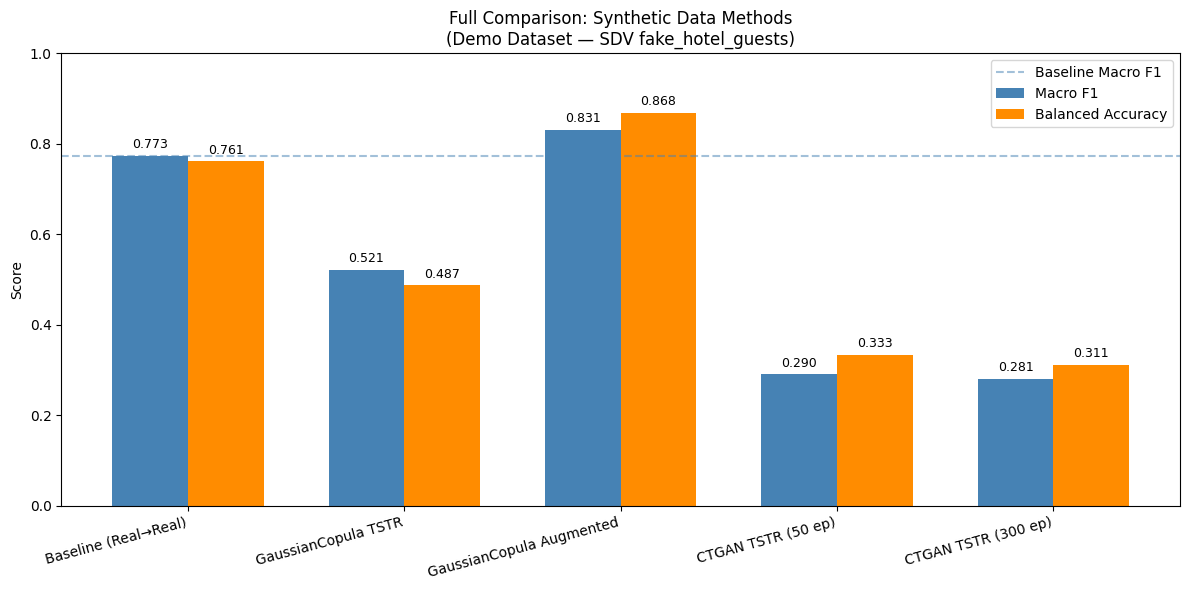

In [14]:
# ── Complete results table ────────────────────────────────────────
results_final = pd.DataFrame({
    'Method': [
        'Baseline (Real→Real)',
        'GaussianCopula TSTR',
        'GaussianCopula Augmented',  # ← YOUR BEST RESULT
        'CTGAN TSTR (50 ep)',
        'CTGAN TSTR (300 ep)',
    ],
    'Macro F1': [
        f1_score(y_test, y_pred,        average='macro'),
        f1_score(y_test, y_pred_gc,     average='macro'),
        f1_score(y_test, y_pred_aug_gc, average='macro'),
        f1_score(y_test, y_pred_ct,     average='macro'),
        f1_score(y_test, y_pred_ct300,  average='macro'),
    ],
    'Balanced Accuracy': [
        balanced_accuracy_score(y_test, y_pred),
        balanced_accuracy_score(y_test, y_pred_gc),
        balanced_accuracy_score(y_test, y_pred_aug_gc),
        balanced_accuracy_score(y_test, y_pred_ct),
        balanced_accuracy_score(y_test, y_pred_ct300),
    ]
}).round(4)

print(results_final.to_string(index=False))

# ── Bar chart ─────────────────────────────────────────────────────
x = np.arange(len(results_final))
w = 0.35
fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - w/2, results_final['Macro F1'],         w,
            label='Macro F1', color='steelblue')
b2 = ax.bar(x + w/2, results_final['Balanced Accuracy'], w,
            label='Balanced Accuracy', color='darkorange')

# Baseline reference line
ax.axhline(y=0.7734, color='steelblue', linestyle='--',
           alpha=0.5, label='Baseline Macro F1')

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(results_final['Method'], rotation=15, ha='right')
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('Full Comparison: Synthetic Data Methods\n(Demo Dataset — SDV fake_hotel_guests)')
ax.legend()
plt.tight_layout()
plt.show()